## MLS WS 2025/26 Exercise 3d: Spam Email Classification with Machine Learning and Deep Learning (39 Points)
*Adapted from an exercise created by Dennis Eisermann*

This notebook introduces basic concepts of email filtering. Your task is to build a robust spam email classifier using a [combined dataset of emails](https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset). This dataset uses the labels 1 for spam and 0 for ham. The dataset contains the columns 'text_combined', which is the email content and 'label'.

#### Learning Goals:
<ul>
<li>Understand text data preprocessing techniques (TF-IDF, tokenization).</li>
<li>Perform exploratory data analysis (EDA) on text data.</li>
<li>Train and evaluate traditional ML models (e.g., Logistic Regression, Random Forest).</li>
<li>Compare model performance using metrics like accuracy, precision, recall, and F1-score.</li>
<li>Interpret confusion matrices to identify model weaknesses.</li>
</ul>

### Task 1 – Setup and Preprocessing (3 Points)



1. Install and import the necessary libraries: pandas, numpy, matplotlib, seaborn and sklearn.

In [1]:
!pip install pandas matplotlib seaborn numpy nltk xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 6.1 MB/s  0:00:00
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.0/72.0 MB 6.5 MB/s eta 0:00:11
   - -------------------------------------- 2.6/72.0 MB 6.6 MB/s eta 0:00:11
   - -------------------------------------- 3.4/72.0 MB 6.1 MB/s eta 0:00:12
   -- ------------------------------------- 4.7/72.0 MB 6.0 MB/s eta 0:00:12
   --- ------------------------------------ 6.0/72.0 MB 6.0 MB/s eta 0:00:12
   --- ------------------------------------ 7.1/72.0 MB 6.0 MB/s eta 0:00:11
   ---- ----------------------------------- 8.1/72.0 MB 5.9 MB/s eta 0:00:11
   ----- ---------------------------------- 9.2/72.0 MB 5.8 MB/s eta 0:00:11
   ----- ---------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer


2. Load the dataset into a pandas Dataframe. (1 Point)

In [11]:
import pandas as pd
import zipfile

# ZIP-Datei öffnen und alles extrahieren
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("data")  # entpackt alle Dateien in den Ordner "data"

# Liste der enthaltenen CSV-Dateien
csv_files = [
    "CEAS_08.csv",
    "Enron.csv",
    "Ling.csv",
    "Nazario.csv",
    "Nigerian_Fraud.csv",
    "SpamAssasin.csv",
    "phishing_email.csv"
]

# Dictionary für alle DataFrames
dataframes = {}

# Jede CSV laden und im Dictionary speichern
for file in csv_files:
    path = f"data/{file}"
    df = pd.read_csv(path)
    dataframes[file] = df
    print(f"--- {file} ---")
    print(df.head(), "\n")

# Zugriff auf ein bestimmtes DataFrame:
# Beispiel: Enron-Datensatz
CEAS_08_df = dataframes["CEAS_08.csv"]
enron_df = dataframes["Enron.csv"]
Ling_df = dataframes["Ling.csv"]
Nazario_df = dataframes["Nazario.csv"]
Nigerian_Fraud_df = dataframes["Nigerian_Fraud.csv"]
phishing_email_df = dataframes["phishing_email.csv"]


--- CEAS_08.csv ---
                                              sender  \
0                   Young Esposito <Young@iworld.de>   
1                       Mok <ipline's1983@icable.ph>   
2  Daily Top 10 <Karmandeep-opengevl@universalnet...   
3                 Michael Parker <ivqrnai@pobox.com>   
4  Gretchen Suggs <externalsep1@loanofficertool.com>   

                                         receiver  \
0                     user4@gvc.ceas-challenge.cc   
1                   user2.2@gvc.ceas-challenge.cc   
2                   user2.9@gvc.ceas-challenge.cc   
3  SpamAssassin Dev <xrh@spamassassin.apache.org>   
4                   user2.2@gvc.ceas-challenge.cc   

                              date  \
0  Tue, 05 Aug 2008 16:31:02 -0700   
1  Tue, 05 Aug 2008 18:31:03 -0500   
2  Tue, 05 Aug 2008 20:28:00 -1200   
3  Tue, 05 Aug 2008 17:31:20 -0600   
4  Tue, 05 Aug 2008 19:31:21 -0400   

                                             subject  \
0                          Never agree 

3. Encode the label column by replacing 0 with 'ham' and 1  with 'spam'. Print the header of the result. (1 Point)

In [104]:
# Beispiel: wir nehmen an, die Spalte heißt 'label'
CEAS_08_df['label'] = CEAS_08_df['label'].replace({0: 'ham', 1: 'spam'})
enron_df['label'] = enron_df['label'].replace({0: 'ham', 1: 'spam'})
Ling_df['label'] = Ling_df['label'].replace({0: 'ham', 1: 'spam'})
Nazario_df['label'] = Nazario_df['label'].replace({0: 'ham', 1: 'spam'})
Nigerian_Fraud_df['label'] = Nigerian_Fraud_df['label'].replace({0: 'ham', 1: 'spam'})
phishing_email_df['label'] = phishing_email_df['label'].replace({0: 'ham', 1: 'spam'})

print("--- CEAS_08_df ---")
print(CEAS_08_df.head(), "\n")

print("--- enron_df ---")
print(enron_df.head(), "\n")

print("--- Ling_df ---")
print(Ling_df.head(), "\n")

print("--- Nazario_df ---")
print(Nazario_df.head(), "\n")

print("--- Nigerian_Fraud_df ---")
print(Nigerian_Fraud_df.head(), "\n")

print("--- phishing_email_df ---")
print(phishing_email_df.head(), "\n")



--- CEAS_08_df ---
                                              sender  \
0                   Young Esposito <Young@iworld.de>   
1                       Mok <ipline's1983@icable.ph>   
2  Daily Top 10 <Karmandeep-opengevl@universalnet...   
3                 Michael Parker <ivqrnai@pobox.com>   
4  Gretchen Suggs <externalsep1@loanofficertool.com>   

                                         receiver  \
0                     user4@gvc.ceas-challenge.cc   
1                   user2.2@gvc.ceas-challenge.cc   
2                   user2.9@gvc.ceas-challenge.cc   
3  SpamAssassin Dev <xrh@spamassassin.apache.org>   
4                   user2.2@gvc.ceas-challenge.cc   

                              date  \
0  Tue, 05 Aug 2008 16:31:02 -0700   
1  Tue, 05 Aug 2008 18:31:03 -0500   
2  Tue, 05 Aug 2008 20:28:00 -1200   
3  Tue, 05 Aug 2008 17:31:20 -0600   
4  Tue, 05 Aug 2008 19:31:21 -0400   

                                             subject  \
0                          Never agree t

In [13]:
datasets = {
    "CEAS_08_df": CEAS_08_df,
    "enron_df": enron_df,
    "Ling_df": Ling_df,
    "Nazario_df": Nazario_df,
    "Nigerian_Fraud_df": Nigerian_Fraud_df,
    "phishing_email_df": phishing_email_df
}

for name, df in datasets.items():
    print(f"--- {name} ---")
    print("Shape:", df.shape)              # Anzahl Zeilen/Spalten
    print("\nInfo:")
    print(df.info())                       # Spalten, Datentypen, Missing Values
    print("\nLabel-Verteilung:")
    print(df['label'].value_counts())      # Anzahl ham/spam
    print("\nStatistische Übersicht:")
    print(df.describe(include='all'))      # Statistiken für numerische & kategoriale Daten
    print("\n" + "-"*50 + "\n")


--- CEAS_08_df ---
Shape: (39154, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  object
 6   urls      39154 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 2.1+ MB
None

Label-Verteilung:
label
spam    21842
ham     17312
Name: count, dtype: int64

Statistische Übersicht:
                                   sender                     receiver  \
count                               39154                        38692   
unique                              24578                         3693   
top     qydlqcws-iacfym@issues.apache.org  user6@gvc.ceas-challenge.cc   
freq                                  462          

4. Prepare training and test data for later use. Split the data into 70% training and 30% testing sets. Set 42 as random seed for reproducibility. Check for missing values and handle them if necessary. (1 Point)

In [14]:
# Ergebnisse speichern
splits = {}

for name, df in datasets.items():
    print(f"--- {name} ---")
    
    # 1. Missing Values prüfen
    print("Missing values per column:")
    print(df.isnull().sum())
    
    # 2. Fehlende Werte behandeln (hier: entfernen)
    df = df.dropna()
    
    # 3. Features und Label trennen
    X = df.drop("label", axis=1)
    y = df["label"]
    
    # 4. Train/Test-Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Ergebnisse speichern
    splits[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
    
    # Überblick
    print("Train size:", X_train.shape, " Test size:", X_test.shape)
    print("Label distribution (train):")
    print(y_train.value_counts())
    print("Label distribution (test):")
    print(y_test.value_counts())
    print("\n" + "-"*50 + "\n")


--- CEAS_08_df ---
Missing values per column:
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64
Train size: (27068, 6)  Test size: (11601, 6)
Label distribution (train):
label
spam    15279
ham     11789
Name: count, dtype: int64
Label distribution (test):
label
spam    6548
ham     5053
Name: count, dtype: int64

--------------------------------------------------

--- enron_df ---
Missing values per column:
subject    198
body         0
label        0
dtype: int64
Train size: (20698, 2)  Test size: (8871, 2)
Label distribution (train):
label
ham     11054
spam     9644
Name: count, dtype: int64
Label distribution (test):
label
ham     4737
spam    4134
Name: count, dtype: int64

--------------------------------------------------

--- Ling_df ---
Missing values per column:
subject    62
body        0
label       0
dtype: int64
Train size: (1957, 2)  Test size: (840, 2)
Label distribution (train):
label
ham     1

### Task 2 – Data Analysis (12 Points)

Analyse the data bit in order to find out how the dataset is structured, and to see how text data can be processed to filter for the meaningful features later.

1. Calculate and visualize the class distribution (spam vs. ham) using a bar plot. (1 Point)

Class distribution:
label
spam    42891
ham     39595
Name: count, dtype: int64


C:\Users\Simon\AppData\Local\Temp\ipykernel_40856\3897608373.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


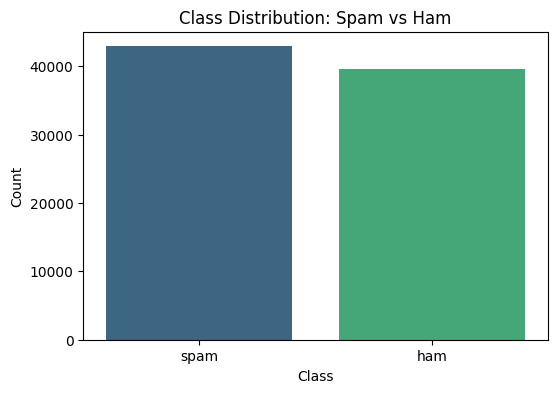

In [15]:
# Angenommen, dein DataFrame heißt df und hat die Spalte 'label'
class_counts = df['label'].value_counts()

# Ausgabe der Verteilung
print("Class distribution:")
print(class_counts)

# Balkendiagramm erstellen
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution: Spam vs Ham")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


2. Compute the average word count per email for spam and ham. Plot the distributions as bar plots. (2 Points)

Durchschnittliche Wortanzahl pro Klasse:
label
ham     203.182068
spam    121.342543
Name: word_count, dtype: float64


C:\Users\Simon\AppData\Local\Temp\ipykernel_40856\1783400071.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_counts.index, y=avg_counts.values, palette="viridis")


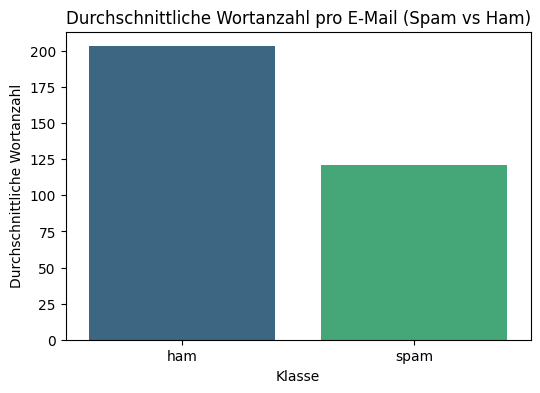

In [20]:
# Angenommen, dein DataFrame heißt df und hat die Spalten 'label' und 'text'
# Schritt 1: Wortanzahl pro E-Mail berechnen
df['word_count'] = df['text_combined'].apply(lambda x: len(str(x).split()))

# Schritt 2: Durchschnittliche Wortanzahl pro Klasse berechnen
avg_counts = df.groupby('label')['word_count'].mean()

print("Durchschnittliche Wortanzahl pro Klasse:")
print(avg_counts)

# Schritt 3: Balkendiagramm zeichnen
plt.figure(figsize=(6,4))
sns.barplot(x=avg_counts.index, y=avg_counts.values, palette="viridis")
plt.title("Durchschnittliche Wortanzahl pro E-Mail (Spam vs Ham)")
plt.xlabel("Klasse")
plt.ylabel("Durchschnittliche Wortanzahl")
plt.show()


3. Identify the top 10 most frequent words in spam emails by following the process below. (overall 4 Points)

   It is advisable to join the spam emails into one string.

   So-called stopwords carry little semantic meaning and removing them improves performance and results.
   Use the stopword list from the [nltk package](https://www.geeksforgeeks.org/python/introduction-to-nltk-tokenization-stemming-lemmatization-pos-tagging/) to remove stop words (2 Points).

   Calculate the frequencies for the remaining words and print out the 10 most frequent ones together with their number of occurrence. (2 Points)

In [21]:
import nltk
nltk.download('stopwords')

# Angenommen, dein DataFrame heißt df und hat die Spalten 'label' und 'text'

# 1. Nur Spam-E-Mails auswählen
spam_emails = df[df['label'] == 'spam']['text_combined']

# 2. Alle Spam-E-Mails zu einem großen String zusammenfügen
spam_text = " ".join(spam_emails.astype(str))

# 3. Tokenisierung (in Wörter zerlegen)
words = spam_text.lower().split()

# 4. Stopwords entfernen
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w.isalpha() and w not in stop_words]

# 5. Häufigkeiten berechnen
word_freq = Counter(filtered_words)

# 6. Top-10 häufigste Wörter ausgeben
top_10 = word_freq.most_common(10)

print("Top 10 häufigste Wörter in Spam-E-Mails:")
for word, freq in top_10:
    print(f"{word}: {freq}")



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Simon\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Top 10 häufigste Wörter in Spam-E-Mails:
aug: 28037
email: 26289
top: 23169
company: 18244
please: 18049
money: 17829
account: 16337
news: 15935
one: 15680
us: 15480


4. Repeat the previous steps for the 'ham' emails. (1 Point)

In [23]:
import nltk
nltk.download('stopwords')

# Angenommen, dein DataFrame heißt df und hat die Spalten 'label' und 'text'

# 1. Nur Spam-E-Mails auswählen
spam_emails = df[df['label'] == 'ham']['text_combined']

# 2. Alle Spam-E-Mails zu einem großen String zusammenfügen
spam_text = " ".join(spam_emails.astype(str))

# 3. Tokenisierung (in Wörter zerlegen)
words = spam_text.lower().split()

# 4. Stopwords entfernen
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w.isalpha() and w not in stop_words]

# 5. Häufigkeiten berechnen
word_freq = Counter(filtered_words)

# 6. Top-10 häufigste Wörter ausgeben
top_10 = word_freq.most_common(10)

print("Top 10 häufigste Wörter in Spam-E-Mails:")
for word, freq in top_10:
    print(f"{word}: {freq}")



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Simon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 10 häufigste Wörter in Spam-E-Mails:
enron: 53880
ect: 34721
submissionid: 32246
would: 25383
new: 24807
please: 22077
submission: 21027
added: 20790
one: 20308
aug: 19831


5. Describe in two sentences which differences you see when comparing your results for the most frequent words in spam and ham emails. (1 Point)

For Spam the Variance of words seems to be higher because the count for the most common words is much higher for the Ham classified data. There are simmiliar words but also some major topic differences words like "money, company or account". Non Spam Emails are more abstract.

6. Visualize the distribution of email lengths (character count) for both classes. Use a KDE Plot from the [seaborn package](https://www.geeksforgeeks.org/r-data-visualization/kde-plot-visualization-with-pandas-and-seaborn/) for the plots. (3 Points)

In [41]:
print(list(df.columns))

# Top 10 E-Mails mit den meisten Wörtern
top10 = df.sort_values(by='word_count', ascending=False).head(10)

print(top10[['label', 'word_count', 'text_combined']])


df = df[df['word_count'] <= 20000]


['text_combined', 'label', 'word_count', 'char_count']
      label  word_count                                      text_combined
11395   ham       18118  enron mentions 11 09 01 11 10 01 rival buy enr...
11362   ham       16759  enron mentions fall power giant bailout unlike...
11373   ham       14264  enron mentions 11 24 01 11 25 01 accounting pe...
11368   ham       13986  enron mentions enron dynegy discuss plan cut p...
11367   ham       13816  enron mentions bet employer plunge enron stock...
36260   ham       12782  whatiscom ndetplliststechtargetcom whatiscom f...
10676   ham       12159  enron mentions enron discusses credit line 1 b...
11397   ham       11668  enron mentions enron slashes profits since 199...
11387   ham       10919  enron mentions enron lay turns severance pay w...
11400   ham       10505  enron mentions dynegy talks purchasing enron d...


C:\Users\Simon\AppData\Local\Temp\ipykernel_40856\2671071416.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['char_count'] = df['text_combined'].apply(lambda x: len(str(x)))


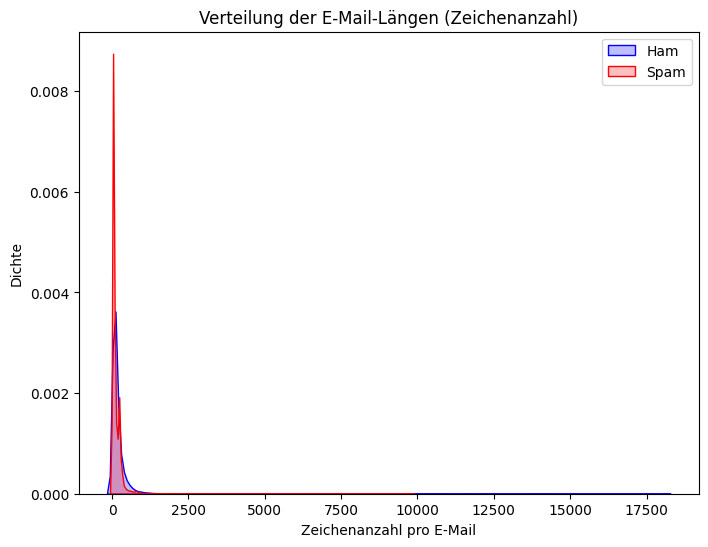

In [40]:
# 1. Zeichenanzahl pro E-Mail berechnen
df['char_count'] = df['text_combined'].apply(lambda x: len(str(x)))

# 2. KDE-Plot erstellen
plt.figure(figsize=(8,6))
sns.kdeplot(data=df[df['label'] == 'ham'], x='word_count', label='Ham', fill=True, color='blue')
sns.kdeplot(data=df[df['label'] == 'spam'], x='word_count', label='Spam', fill=True, color='red')

# 3. Plot beschriften
plt.title("Verteilung der E-Mail-Längen (Zeichenanzahl)")
plt.xlabel("Zeichenanzahl pro E-Mail")
plt.ylabel("Dichte")
plt.legend()
plt.show()


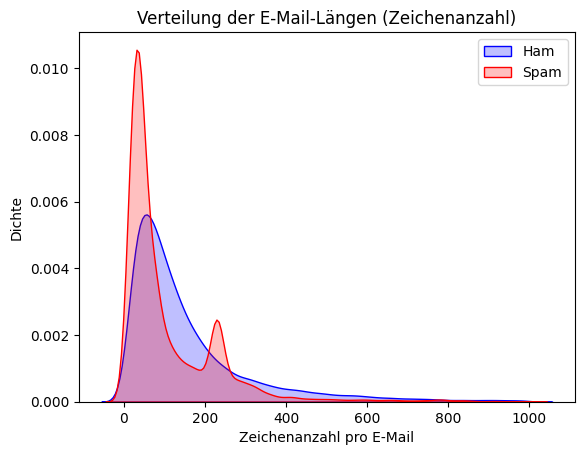

In [48]:
filtered = df[(df['word_count'] < 1000)]


sns.kdeplot(data=filtered[filtered['label'] == 'ham'], x='word_count', label='Ham', fill=True, color='blue')
sns.kdeplot(data=filtered[filtered['label'] == 'spam'], x='word_count', label='Spam', fill=True, color='red')

# 3. Plot beschriften
plt.title("Verteilung der E-Mail-Längen (Zeichenanzahl)")
plt.xlabel("Zeichenanzahl pro E-Mail")
plt.ylabel("Dichte")
plt.legend()
plt.show()
 

In [71]:
combined_email_splits = splits['phishing_email_df']
print(combined_email_splits.keys())
X_train = combined_email_splits['X_train']
print(X_train)
X_test = combined_email_splits['X_test']
y_train = combined_email_splits['y_train']
print(y_train)
y_test = combined_email_splits['y_test']



dict_keys(['X_train', 'X_test', 'y_train', 'y_test'])
                                           text_combined
42620  smithsonianstore krkythhaweuryyvqemailsmithson...
42022  godart shirl clairemckibbenedglegalcom dear c6...
13989  revised curtailment banner eol banner eol post...
44018  efram sanjeev chammtctrainscom new jessica sim...
7682   ebs approach storage trading hi ravi thanks no...
...                                                  ...
71180  aldis verity lamebordimbroglioorg add passion ...
82325  noreplystandardbankcozanoreplystandardbankcoza...
74498  solocdm deedsmisaculinknet tried several ways ...
49486  katy caron noemifatalnavagksoftcom replica cla...
16121  curve manager use curve manager know experienc...

[57740 rows x 1 columns]
42620     ham
42022    spam
13989     ham
44018    spam
7682      ham
         ... 
71180    spam
82325    spam
74498     ham
49486    spam
16121     ham
Name: label, Length: 57740, dtype: object


### Task 3 – Feature Preparation (6 Points)

In this task, you prepare the data for later use in training and testing. Therefore, filter out unnecessary stopwords and punctuation and transform the data.

1. The first step is to preprocess the text of the emails. Write a function to convert it to lowercase, remove punctuation, tokenize it (see useful nltk functions for this) and remove the stopwords for each mail in the dataset. Use the stopword list from the [nltk package](https://www.geeksforgeeks.org/python/introduction-to-nltk-tokenization-stemming-lemmatization-pos-tagging/). (3 Points)

In [85]:
'''
# Ergebnisse speichern
    splits[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
'''
import string
from nltk.corpus import stopwords

def preprocess_email(text):
    # Lowercase
    text = text.lower()
    # Satzzeichen entfernen
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenisierung (einfaches Split)
    tokens = text.split()
    # Stopwords entfernen
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if w not in stop_words]
    return " ".join(filtered_tokens)


# Beispiel: Anwendung auf eine Spalte 'text' im DataFrame

X_train['processed_text'] = X_train['text_combined'].apply(preprocess_email)
X_test['processed_text'] = X_test['text_combined'].apply(preprocess_email)

# Kontrolle: erste Zeilen anzeigen
print(X_train[['text_combined', 'processed_text']].head())
print(X_test[['text_combined', 'processed_text']].head())


                                           text_combined  \
42620  smithsonianstore krkythhaweuryyvqemailsmithson...   
42022  godart shirl clairemckibbenedglegalcom dear c6...   
13989  revised curtailment banner eol banner eol post...   
44018  efram sanjeev chammtctrainscom new jessica sim...   
7682   ebs approach storage trading hi ravi thanks no...   

                                          processed_text  
42620  smithsonianstore krkythhaweuryyvqemailsmithson...  
42022  godart shirl clairemckibbenedglegalcom dear c6...  
13989  revised curtailment banner eol banner eol post...  
44018  efram sanjeev chammtctrainscom new jessica sim...  
7682   ebs approach storage trading hi ravi thanks no...  
                                           text_combined  \
37719  chmessomfuartekstilcomtr neighbour wants send ...   
35571  cnet techspecials zogs_rzjvdefe_xwpuzo_gsrzjvd...   
13123  performance review process east power trading ...   
55196  daily top 10 councilb_1975dafengcom da

2. Write a function which uses [TfidfVectorizer](https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/) to create TF-IDF features (max_features=5000). The matrix of the vectorizer can directly be used as output and does not have to be converted to a Dataframe or array! (2 Points)

In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

def create_tfidf_features(corpus):
    """
    Erstellt TF-IDF Features aus einem Textkorpus.
    - corpus: Liste oder Pandas Series mit Texten
    - max_features = 5000
    Rückgabe: TF-IDF-Matrix (sparse matrix)
    """
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(corpus)
    return tfidf_matrix, vectorizer


3. Use the function to transform the training and testing data. (1 Point)

In [88]:
# Angenommen, du hast X_train und X_test aus dem vorherigen Split
# und die Funktion create_tfidf_features(corpus) ist definiert

# Training-Daten transformieren
X_train_tfidf, tfidf_vectorizer = create_tfidf_features(X_train['processed_text'].values)

# Test-Daten mit demselben Vektorizer transformieren
X_test_tfidf = tfidf_vectorizer.transform(X_test['processed_text'].values)

print("Train TF-IDF Shape:", X_train_tfidf.shape)
print("Test TF-IDF Shape:", X_test_tfidf.shape)


Train TF-IDF Shape: (57740, 5000)
Test TF-IDF Shape: (24746, 5000)


### Task 4 – Model Training (6 Points)

Train three different classifiers to distinguish between ham and spam.

1. Train a Logistic Regression model using the TF-IDF features. (2 Points)

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Angenommen, du hast:
# X_train_tfidf, X_test_tfidf (TF-IDF Features)
# y_train, y_test (Labels)

# 1. Modell initialisieren
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Modell trainieren
log_reg.fit(X_train_tfidf, y_train)

# 3. Vorhersagen auf Testdaten
y_pred = log_reg.predict(X_test_tfidf)

# 4. Ergebnisse ausgeben
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9820172957245615

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     11879
           1       0.98      0.98      0.98     12867

    accuracy                           0.98     24746
   macro avg       0.98      0.98      0.98     24746
weighted avg       0.98      0.98      0.98     24746



2. Train a Random Forest model with 100 estimators. (2 Points)

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Angenommen, du hast:
# X_train_tfidf, X_test_tfidf (TF-IDF Features)
# y_train, y_test (Labels)

# 1. Modell initialisieren
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Modell trainieren
rf_model.fit(X_train_tfidf, y_train)

# 3. Vorhersagen auf Testdaten
y_pred_rf = rf_model.predict(X_test_tfidf)

# 4. Ergebnisse ausgeben
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9859775317222985

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     11879
           1       0.99      0.99      0.99     12867

    accuracy                           0.99     24746
   macro avg       0.99      0.99      0.99     24746
weighted avg       0.99      0.99      0.99     24746



3. Train an [XGBoost classifier](https://xgboost.readthedocs.io/en/stable/get_started.html). (2 Points)


In [107]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Angenommen, du hast:
# X_train_tfidf, X_test_tfidf (TF-IDF Features)
# y_train, y_test (Labels)

# 1. Modell initialisieren
xgb_model = XGBClassifier(
    n_estimators=100,       # Anzahl der Bäume
    max_depth=6,            # maximale Tiefe pro Baum
    learning_rate=0.1,      # Schrittweite
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'   # verhindert Warnungen
)

# Spam = 1, Ham = 0
y_train_num = y_train.replace({'spam': 1, 'ham': 0})
y_test_num  = y_test.replace({'spam': 1, 'ham': 0})

print(y_train.head())

# 2. Modell trainieren
xgb_model.fit(X_train_tfidf, y_train_num)

# 3. Vorhersagen auf Testdaten
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# 4. Ergebnisse ausgeben
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


42620    0
42022    1
13989    0
44018    1
7682     0
Name: label, dtype: int64


C:\Users\Simon\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [12:44:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9610037985937121

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     11879
           1       0.95      0.98      0.96     12867

    accuracy                           0.96     24746
   macro avg       0.96      0.96      0.96     24746
weighted avg       0.96      0.96      0.96     24746



### Task 5 – Evaluation (12 Points)

In this task you evaluate the performances of the three models with several different statistics and draw conclusions.

1. Predict the labels of the test set for all three models. (1 Point)

In [108]:
# 1. Logistic Regression
y_pred_logreg = log_reg.predict(X_test_tfidf)

# 2. Random Forest
y_pred_rf = rf_model.predict(X_test_tfidf)

# 3. XGBoost
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# Kontrolle: erste 10 Vorhersagen je Modell
print("Logistic Regression Predictions:", y_pred_logreg[:10])
print("Random Forest Predictions:", y_pred_rf[:10])
print("XGBoost Predictions:", y_pred_xgb[:10])


Logistic Regression Predictions: [1 0 0 1 1 1 0 0 0 1]
Random Forest Predictions: [1 0 0 1 1 1 0 0 0 1]
XGBoost Predictions: [1 0 0 1 1 1 0 0 0 1]


2. Compute accuracy, precision, recall, F1-score, and ROC-AUC for all three models using 'sklearn.metrics'. Print your results. (3 Point)

In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Angenommen, du hast:
# y_test (wahre Labels)
# y_pred_logreg, y_pred_rf, y_pred_xgb (Vorhersagen der Modelle)

def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))
    print()

# Ergebnisse für alle drei Modelle
evaluate_model("Logistic Regression", y_test, y_pred_logreg)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)


--- Logistic Regression ---
Accuracy: 0.9820172957245615
Precision: 0.9808764323319913
Recall: 0.9846117976218233
F1-Score: 0.982740565488888
ROC-AUC: 0.9819094007891928

--- Random Forest ---
Accuracy: 0.9859775317222985
Precision: 0.9877668692535453
Recall: 0.9852335431724567
F1-Score: 0.9864985798217968
ROC-AUC: 0.9860084712242451

--- XGBoost ---
Accuracy: 0.9610037985937121
Precision: 0.945034400239306
Recall: 0.9821248154192896
F1-Score: 0.963222683791303
ROC-AUC: 0.9601254601551369



3. Generate confusion matrices for all models. Plot them as heatmaps. (3 Points)

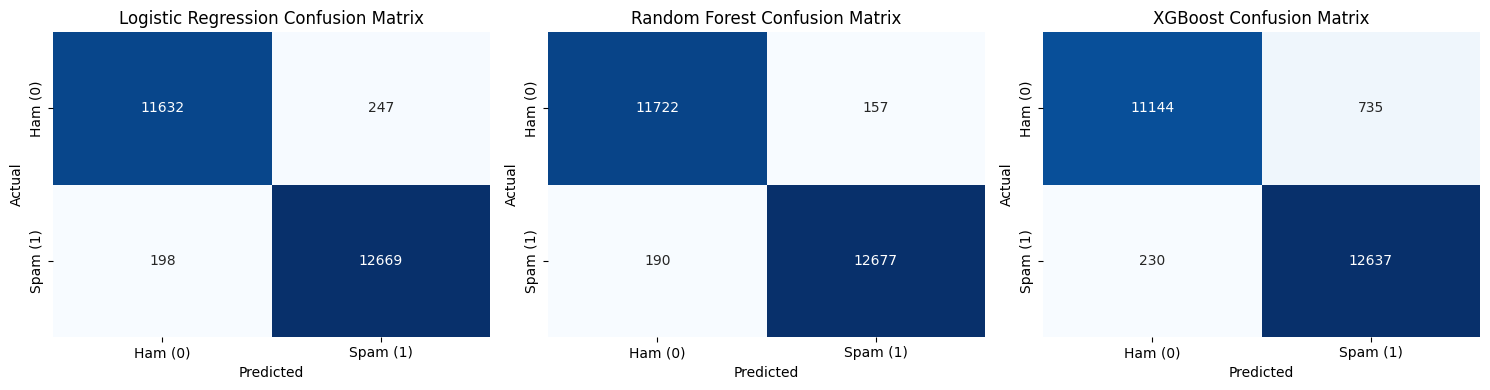

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Angenommen, du hast y_test und die Vorhersagen der drei Modelle:
# y_pred_logreg, y_pred_rf, y_pred_xgb

models = {
    "Logistic Regression": y_pred_logreg,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

plt.figure(figsize=(15, 4))

for i, (name, y_pred) in enumerate(models.items(), 1):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Ham (0)', 'Spam (1)'],
                yticklabels=['Ham (0)', 'Spam (1)'])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


4. Compare ROC-AUC scores across all models using a bar plot. (1 Point)

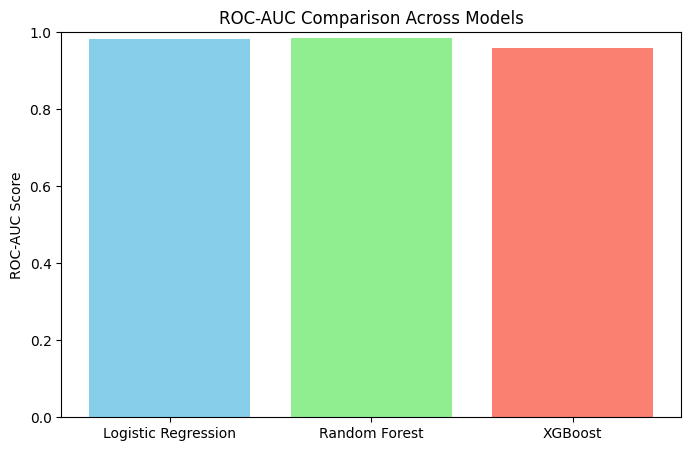

Logistic Regression: 0.9819
Random Forest: 0.9860
XGBoost: 0.9601


In [111]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Angenommen, du hast y_test und die Vorhersagen:
# y_pred_logreg, y_pred_rf, y_pred_xgb

# ROC-AUC Scores berechnen
roc_scores = {
    "Logistic Regression": roc_auc_score(y_test, y_pred_logreg),
    "Random Forest": roc_auc_score(y_test, y_pred_rf),
    "XGBoost": roc_auc_score(y_test, y_pred_xgb)
}

# Bar Plot erstellen
plt.figure(figsize=(8, 5))
plt.bar(roc_scores.keys(), roc_scores.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel("ROC-AUC Score")
plt.title("ROC-AUC Comparison Across Models")
plt.ylim(0, 1)  # Werte liegen zwischen 0 und 1
plt.show()

# Kontrolle: Werte ausgeben
for model, score in roc_scores.items():
    print(f"{model}: {score:.4f}")


5. Identify which model has the highest precision and explain shortly why this matters for spam detection. (2 Points)

Random Forest has the highest precision with 98,7%. Because it identifies how much of the classified spam is actual spam
Precision= True Positives (TP) / (True Positives (TP) + False Positives (FP))

6. Interpret the confusion matrix for the best model: (2 Points)

    * Name the types of errors that are most common (false positives vs. false negatives).
    * Suggest improvements to reduce these errors.

The best modell is also random forest because there are the least false positives and false negatives.
Random forest has the most errors with false negatives.

Try to find patterns and learn why these instances are falsely classified, possibly more labels.